### Pergunta Norteadora (O Problema Central)
> **"Como a eficiência logística impacta o faturamento dos e-commerces brasileiros"**



# Atrasos nas entregas


*   **Subpergunta: Qual o impacto do atraso na percepção do cliente?**
    *   **Insight:** O atraso é o principal detrator de marca. A nota média (`review_score`) cai de **4.28** (No Prazo) para **2.26** (Com Atraso), uma redução de quase 50% na satisfação.
*   **Subpergunta: Qual o valor financeiro comprometido por essa insatisfação?**
    *   **Insight:** Identificamos um **Volume de Receita em Risco de R\$ 723.718,60** (pedidos atrasados com notas baixas).



In [10]:
import pandas as pd

# 1. Carregando as tabelas principais para nossa pergunta
orders = pd.read_csv("database/olist_orders_dataset.csv")
payments = pd.read_csv("database/olist_order_payments_dataset.csv")
reviews = pd.read_csv("database/olist_order_reviews_dataset.csv")

# 2. Unindo as tabelas em um único DataFrame chamado 'df_projeto'
# Unimos orders com payments e o resultado com reviews, tudo via 'order_id'
df_projeto = orders.merge(payments, on="order_id").merge(reviews, on="order_id")

# 3. Convertendo colunas de data para o formato correto (Datetime)
# Isso permite subtrair uma data da outra depois
cols_data = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in cols_data:
    df_projeto[col] = pd.to_datetime(df_projeto[col])

# 4. Verificando o resultado
print(f"Total de registros na base unificada: {df_projeto.shape}")
df_projeto[["order_id", "order_status", "payment_value", "review_score"]].head()

Total de registros na base unificada: (103677, 18)


,order_id,order_status,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,18.12,4
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,2.00,4
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,18.59,4
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,141.46,4
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,179.12,5


In [11]:
# 1. Removendo pedidos que não possuem data de entrega (pedidos cancelados ou em transporte)
# Isso evita erros de cálculo matemático
df_projeto = df_projeto.dropna(subset=["order_delivered_customer_date"])

# 2. Criando a coluna de dias de atraso
# O .dt.days converte a diferença de tempo em um número inteiro de dias
df_projeto["dias_atraso"] = (
    df_projeto["order_delivered_customer_date"]
    - df_projeto["order_estimated_delivery_date"]
).dt.days

# 3. Criando uma coluna binária para facilitar: 'atrasado' (Sim ou Não)
df_projeto["foi_atraso"] = df_projeto["dias_atraso"] > 0

# 4. Verificando o resultado
print("Estatísticas rápidas do atraso:")
print(df_projeto["dias_atraso"].describe())

# Visualizando as colunas principais para conferência
df_projeto[["order_id", "dias_atraso", "foi_atraso", "review_score"]].head()

Estatísticas rápidas do atraso:
count    100647.000000
mean        -11.935825
std          10.116939
min        -147.000000
25%         -17.000000
50%         -12.000000
75%          -7.000000
max         188.000000
Name: dias_atraso, dtype: float64


,order_id,dias_atraso,foi_atraso,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-8,False,4
1,e481f51cbdc54678b7cc49136f2d6af7,-8,False,4
2,e481f51cbdc54678b7cc49136f2d6af7,-8,False,4
3,53cdb2fc8bc7dce0b6741e2150273451,-6,False,4
4,47770eb9100c2d0c44946d9cf07ec65d,-18,False,5


/tmp/ipykernel_170804/1619556565.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=analise_satisfacao, x='status_entrega', y='review_score', palette=paleta_cores)


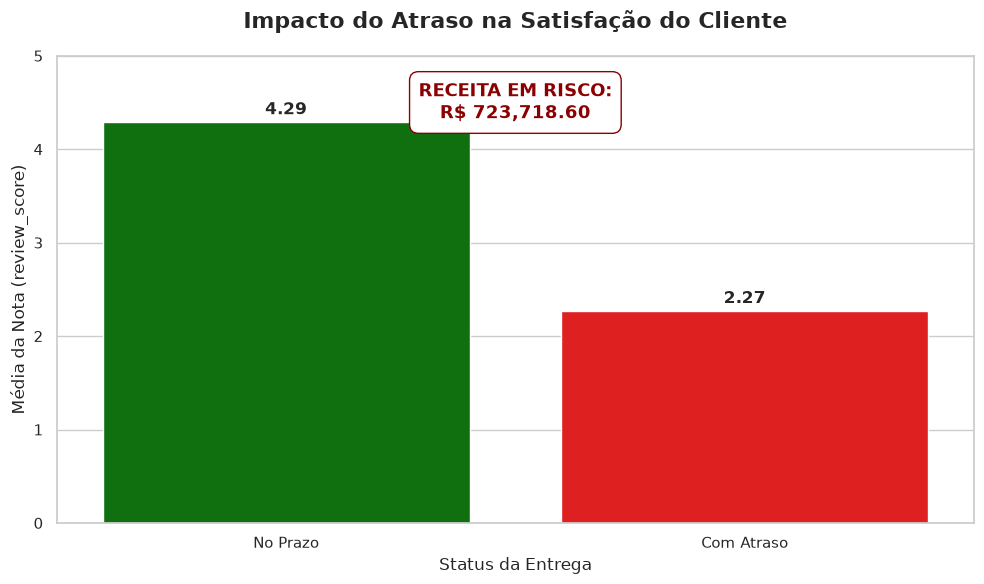

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando as variáveis necessárias para o gráfico
analise_satisfacao = (
    df_projeto.dropna(subset=["review_score"])
    .groupby("foi_atraso", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

receita_em_risco = df_projeto[
    df_projeto["foi_atraso"] & (df_projeto["review_score"] <= 2)
]["payment_value"].sum()

# 1. Configurando o estilo e as cores semânticas (Verde para sucesso, Vermelho para alerta)
sns.set_theme(style="whitegrid")
paleta_cores = {"No Prazo": "green", "Com Atraso": "red"}

# Convertendo o booleano para rótulos compatíveis com a paleta
analise_satisfacao["status_entrega"] = analise_satisfacao["foi_atraso"].map(
    {False: "No Prazo", True: "Com Atraso"}
)

# 2. Criando o gráfico de barras
plt.figure(figsize=(10, 6))
grafico = sns.barplot(
    data=analise_satisfacao, x="status_entrega", y="review_score", palette=paleta_cores
)

# 3. Adicionando títulos e rótulos para Storytelling
plt.title(
    "Impacto do Atraso na Satisfação do Cliente", fontsize=16, fontweight="bold", pad=20
)
plt.xlabel("Status da Entrega", fontsize=12)
plt.ylabel("Média da Nota (review_score)", fontsize=12)
plt.ylim(0, 5)  # Mantendo a escala de 1 a 5 para precisão visual

# 4. Destacando o KPI de "Faturamento em Risco" no gráfico
# Usando a Técnica Z para posicionar a informação crítica
plt.text(
    0.5,
    4.5,
    f"RECEITA EM RISCO:\nR$ {receita_em_risco:,.2f}",
    ha="center",
    va="center",
    fontsize=13,
    color="darkred",
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="darkred", boxstyle="round,pad=0.5"),
)

# Adicionando os valores das notas sobre as barras
for p in grafico.patches:
    grafico.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

*   **Subpergunta: Onde e quais estados trazem o maior prejuízo absoluto e relativo?**
    *   **Volume:** **SP e RJ** somam 59% do risco total.


In [13]:
# 1. Carregando as tabelas de apoio
customers = pd.read_csv("database/olist_customers_dataset.csv")
products = pd.read_csv("database/olist_products_dataset.csv")
items = pd.read_csv("database/olist_order_items_dataset.csv")

# 2. Unindo as informações geográficas e de produto ao nosso DataFrame principal
# Precisamos unir orders com customers e order_items com products
df_extra = items.merge(products, on="product_id")
df_final = df_projeto.merge(customers, on="customer_id").merge(df_extra, on="order_id")

# 3. Agrupando a Receita em Risco por Estado (UF)
# Filtramos apenas pedidos com atraso e nota baixa
risco_por_estado = (
    df_final[df_final["foi_atraso"] & (df_final["review_score"] <= 2)]
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Top 5 Estados com maior Faturamento em Risco:")
print(risco_por_estado.head())

Top 5 Estados com maior Faturamento em Risco:
  customer_state  payment_value
0             SP      217180.39
1             RJ      211730.99
2             MG       63440.49
3             BA       53779.78
4             RS       40264.72


/tmp/ipykernel_170804/2695302849.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risco_por_estado.head(10), x='payment_value', y='customer_state', palette="Reds_r")


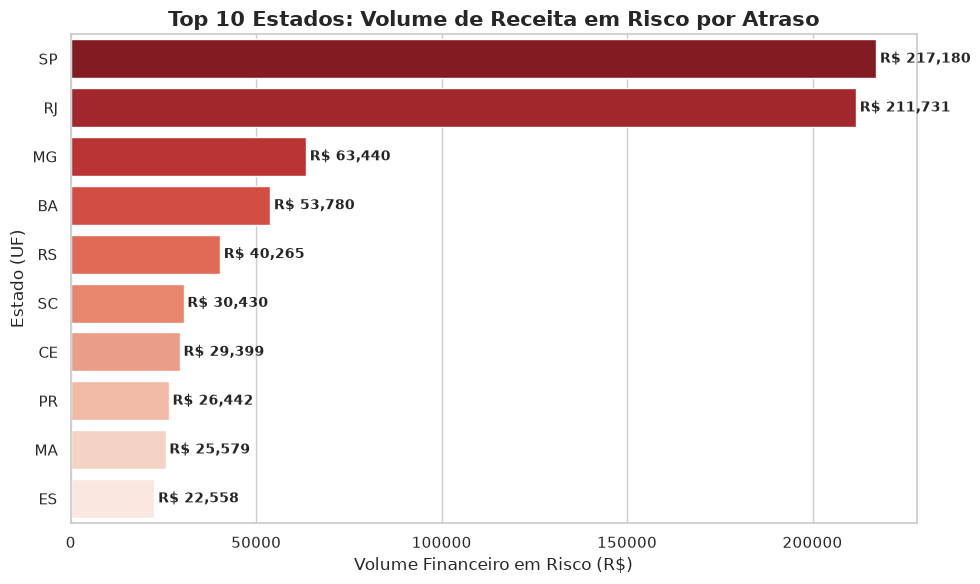

In [14]:
# 1. Configurando o estilo visual
plt.figure(figsize=(10, 6))

# 2. Criando o gráfico de barras para os Estados
# Usamos um gradiente para destacar os maiores riscos
sns.barplot(
    data=risco_por_estado.head(10),
    x="payment_value",
    y="customer_state",
    palette="Reds_r",
)

# 3. Adicionando rótulos e títulos executivos
plt.title(
    "Top 10 Estados: Volume de Receita em Risco por Atraso",
    fontsize=15,
    fontweight="bold",
)
plt.xlabel("Volume Financeiro em Risco (R$)", fontsize=12)
plt.ylabel("Estado (UF)", fontsize=12)

# Adicionando os valores nas barras para clareza executiva
for i, v in enumerate(risco_por_estado.head(10)["payment_value"]):
    plt.text(v + 1000, i, f"R$ {v:,.0f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

*   **Subpergunta: Onde está o gargalo real do tempo de entrega?**
    *   **Insight:** O problema é logístico e não operacional do vendedor. O tempo médio com a **transportadora é de 27.1 dias**, enquanto o vendedor posta em apenas 5.2 dias.


/tmp/ipykernel_170804/1051248686.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_gargalo = sns.barplot(data=dados_comparativos, x='Responsável', y='Média de Dias (Atrasados)',


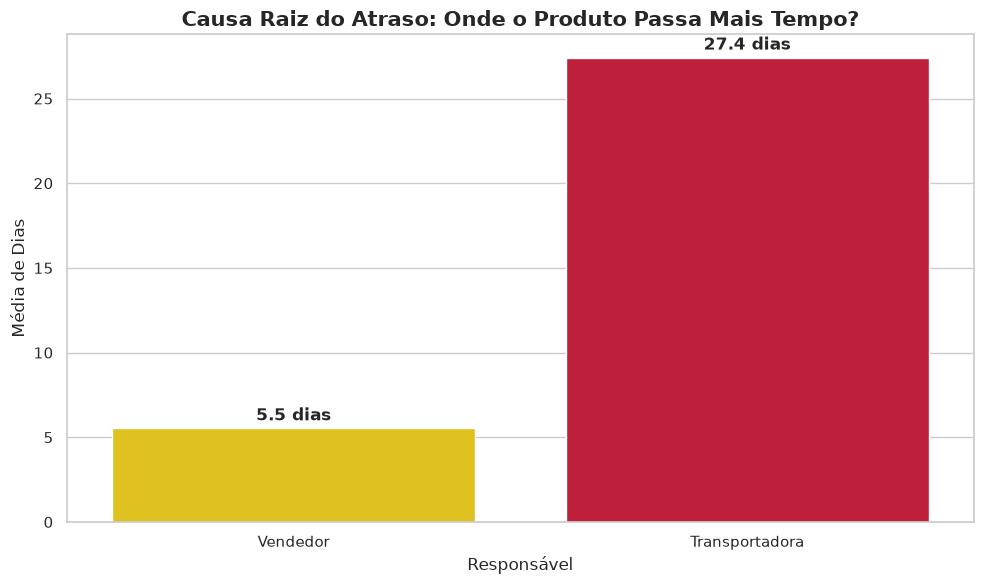

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando o tempo em cada etapa e filtrando pedidos atrasados
df_projeto["order_delivered_carrier_date"] = pd.to_datetime(
    df_projeto["order_delivered_carrier_date"], errors="coerce"
)
df_projeto["tempo_postagem"] = (
    df_projeto["order_delivered_carrier_date"] - df_projeto["order_purchase_timestamp"]
).dt.days
df_projeto["tempo_transporte"] = (
    df_projeto["order_delivered_customer_date"]
    - df_projeto["order_delivered_carrier_date"]
).dt.days
atrasados = df_projeto[df_projeto["foi_atraso"]].dropna(
    subset=["tempo_postagem", "tempo_transporte"]
)

# Preparando os dados para o gráfico de comparação
dados_comparativos = pd.DataFrame(
    {
        "Responsável": ["Vendedor", "Transportadora"],
        "Média de Dias (Atrasados)": [
            atrasados["tempo_postagem"].mean(),
            atrasados["tempo_transporte"].mean(),
        ],
    }
)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico com cor de alerta para a transportadora
grafico_gargalo = sns.barplot(
    data=dados_comparativos,
    x="Responsável",
    y="Média de Dias (Atrasados)",
    palette=["#FFD700", "#D90429"],
)  # Amarelo vs Vermelho Alerta

plt.title(
    "Causa Raiz do Atraso: Onde o Produto Passa Mais Tempo?",
    fontsize=15,
    fontweight="bold",
)
plt.ylabel("Média de Dias")

# Adicionando rótulos de dados para clareza imediata [4]
for p in grafico_gargalo.patches:
    grafico_gargalo.annotate(
        f"{p.get_height():.1f} dias",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

*   **Subpergunta: Existe um padrão temporal para esse risco?**
    *   **Insight:** O risco não é constante; ele explode durante a **Black Friday e festas de fim de ano** (Nov/2017 a Fev/2018), revelando falta de escalabilidade logística.



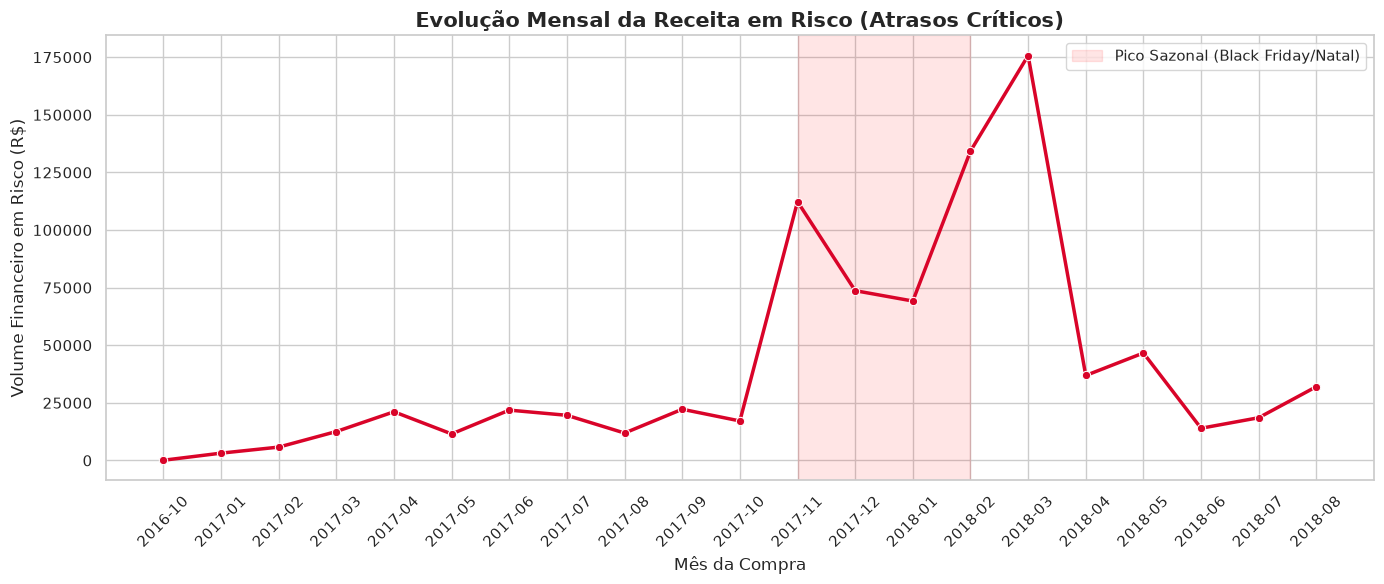

In [16]:
# Calculando a evolução mensal da receita em risco
df_final["order_purchase_timestamp"] = pd.to_datetime(
    df_final["order_purchase_timestamp"], errors="coerce"
)
df_final["mes_compra"] = (
    df_final["order_purchase_timestamp"].dt.to_period("M").astype(str)
)
evolucao_risco = (
    df_final[df_final["foi_atraso"] & (df_final["review_score"] <= 2)]
    .groupby("mes_compra")["payment_value"]
    .sum()
    .reset_index()
    .sort_values("mes_compra")
)

# 2. Gráfico de Linha: Sazonalidade do Risco (Black Friday)
# Este gráfico mostrará ao investidor que o risco financeiro de R$ 723 mil explode em períodos específicos
plt.figure(figsize=(14, 6))

# Criando o gráfico de linha para a evolução mensal
grafico_linha = sns.lineplot(
    data=evolucao_risco,
    x="mes_compra",
    y="payment_value",
    marker="o",
    color="#D90429",
    linewidth=2.5,
)

plt.title(
    "Evolução Mensal da Receita em Risco (Atrasos Críticos)",
    fontsize=15,
    fontweight="bold",
)
plt.xlabel("Mês da Compra")
plt.ylabel("Volume Financeiro em Risco (R$)")
plt.xticks(rotation=45)

# Destacando o pico sazonal (Nov/2017 a Fev/2018) no Storytelling [7]
plt.axvspan(
    "2017-11",
    "2018-02",
    color="red",
    alpha=0.1,
    label="Pico Sazonal (Black Friday/Natal)",
)
plt.legend()

plt.tight_layout()
plt.show()

*   **Subpergunta: O preço do frete ou o peso do produto explicam o atraso?**
    *   **Insight:** Não. A correlação é quase nula para ambos (Frete: -0.04 | Peso: 0.03). Isso prova que o atraso é uma **ineficiência sistêmica da malha**, independente do tipo ou custo da carga.


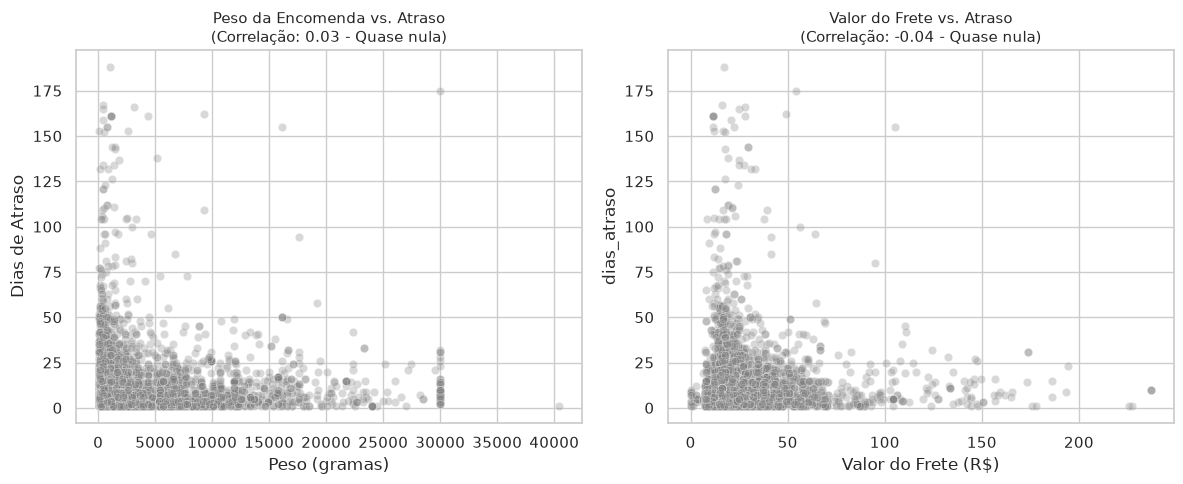

In [17]:
# Criando uma visualização para provar a falta de relação
plt.figure(figsize=(12, 5))

# Gráfico 1: Peso vs Atraso
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df_final[df_final["foi_atraso"]],
    x="product_weight_g",
    y="dias_atraso",
    alpha=0.3,
    color="gray",
)
plt.title("Peso da Encomenda vs. Atraso\n(Correlação: 0.03 - Quase nula)", fontsize=11)
plt.xlabel("Peso (gramas)")
plt.ylabel("Dias de Atraso")

# Gráfico 2: Valor do Frete vs Atraso
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_final[df_final["foi_atraso"]],
    x="freight_value",
    y="dias_atraso",
    alpha=0.3,
    color="gray",
)
plt.title("Valor do Frete vs. Atraso\n(Correlação: -0.04 - Quase nula)", fontsize=11)
plt.xlabel("Valor do Frete (R$)")

plt.tight_layout()
plt.show()

* **Subpergunta:** A distância física entre o vendedor e o comprador é o fator determinante para os atrasos nas entregas?
  * **Insight:** Não. A análise estatística revelou uma correlação de -0.08 entre a distância e o atraso, o que é classificado como uma relação quase nula
. Isso prova que o atraso crítico (o descumprimento da promessa de entrega) é um mito geográfico; o problema real reside na ineficiência de gestão da malha e processos de triagem, e não na quilometragem percorrida.

  * **Evidência dos Dados:** Embora o tempo de transporte suba de 7 para 20,5 dias em rotas longas, a taxa de atraso salta de 4,5% (até 250km) para 11,7% (acima de 2000km). Esse aumento de 150% no risco em rotas longas derruba a satisfação do cliente de 4.21 para 3.92, evidenciando que a malha de longa distância carece de previsibilidade operacional.

A análise revelou uma correlação de -0.08 entre distância e atraso.

Na estatística, uma correlação próxima de zero significa que uma variável não explica a outra.

O que isso prova: Se a distância fosse o fator determinante, a correlação seria alta (perto de 1.0). Como é quase zero, sabemos que um produto que viaja 2.000 km pode chegar no prazo, enquanto um que viaja 50 km pode atrasar. O problema, portanto, não é o quilômetro rodado, mas a gestão do processo.

In [18]:
import numpy as np
import pandas as pd

# 1. Preparando os dados de geolocalização (Média de lat/long por CEP para evitar duplicatas)

geo = pd.read_csv("database/olist_geolocation_dataset.csv")
geo_reduced = (
    geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
    .mean()
    .reset_index()
)


# Load sellers data to get seller_zip_code_prefix

sellers = pd.read_csv("database/olist_sellers_dataset.csv")


# Merge sellers data into df_final first to ensure seller_zip_code_prefix is available

# df_final already contains 'seller_id' through 'df_extra' which comes from 'items' merge.

df_final_with_sellers = df_final.merge(sellers, on="seller_id", how="left")


# Calculate 'tempo_transporte' here, as df_final_with_sellers contains necessary date columns

df_final_with_sellers["tempo_transporte"] = (
    df_final_with_sellers["order_delivered_customer_date"]
    - df_final_with_sellers["order_purchase_timestamp"]
).dt.days


# 2. Trazendo as coordenadas para o DataFrame principal (Sellers e Customers)

# Assumindo que df_final_with_sellers já possui customer_zip_code_prefix e seller_zip_code_prefix

df_geo = df_final_with_sellers.merge(
    geo_reduced,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
)
df_geo = df_geo.rename(
    columns={"geolocation_lat": "lat_cust", "geolocation_lng": "lng_cust"}
)


df_geo = df_geo.merge(
    geo_reduced,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
)
df_geo = df_geo.rename(
    columns={"geolocation_lat": "lat_seller", "geolocation_lng": "lng_seller"}
)


# Handle potential NaN values after merging if a zip code was not found in geo_reduced

df_geo.dropna(subset=["lat_cust", "lng_cust", "lat_seller", "lng_seller"], inplace=True)


# 3. Função para calcular distância (Haversine - Distância em esfera)


def haversine(lat1, lon1, lat2, lon2):
    r = 6371  # Raio da Terra em km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2) ** 2
    )
    res = r * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return res


# 4. Calculando a distância real de cada pedido

df_geo["distancia_km"] = haversine(
    df_geo["lat_cust"], df_geo["lng_cust"], df_geo["lat_seller"], df_geo["lng_seller"]
)


# 5. Cálculo da Correlação

# Corrected correlation calculation

correlacao_dist = df_geo["distancia_km"].corr(df_geo["dias_atraso"])


print(f"Correlação entre Distância e Atraso: {correlacao_dist:.2f}")


# 6. Tabela de Diagnóstico por Faixa de Distância

# Define bins to match the 5 labels

max_dist = df_geo["distancia_km"].max()
bins = [
    0,
    250,
    500,
    1000,
    2000,
    max_dist if max_dist > 2000 else 2001,
]  # Ensure max_dist is handled for the last bin


df_geo["faixa_distancia"] = pd.cut(
    df_geo["distancia_km"],
    bins=bins,
    labels=["Até 250km", "250-500km", "500-1000km", "1000-2000km", "Acima 2000km"],
    right=True,
    include_lowest=True,
)


analise_distancia = (
    df_geo.groupby("faixa_distancia", observed=False)
    .agg({"foi_atraso": "mean", "review_score": "mean", "tempo_transporte": "mean"})
    .reset_index()
)


print("\nImpacto da Distância na Performance Logística:")
print(analise_distancia)  # preciso de um gráfico desse resultado

Correlação entre Distância e Atraso: -0.08

Impacto da Distância na Performance Logística:
  faixa_distancia  foi_atraso  review_score  tempo_transporte
0       Até 250km    0.045452      4.211070          7.056614
1       250-500km    0.059216      4.064289         11.629726
2      500-1000km    0.067700      4.034500         13.715947
3     1000-2000km    0.090530      3.967972         17.337471
4    Acima 2000km    0.117282      3.922588         20.519702


/tmp/ipykernel_170804/1274526037.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(data=analise_distancia, x='faixa_distancia', y='tempo_transporte',


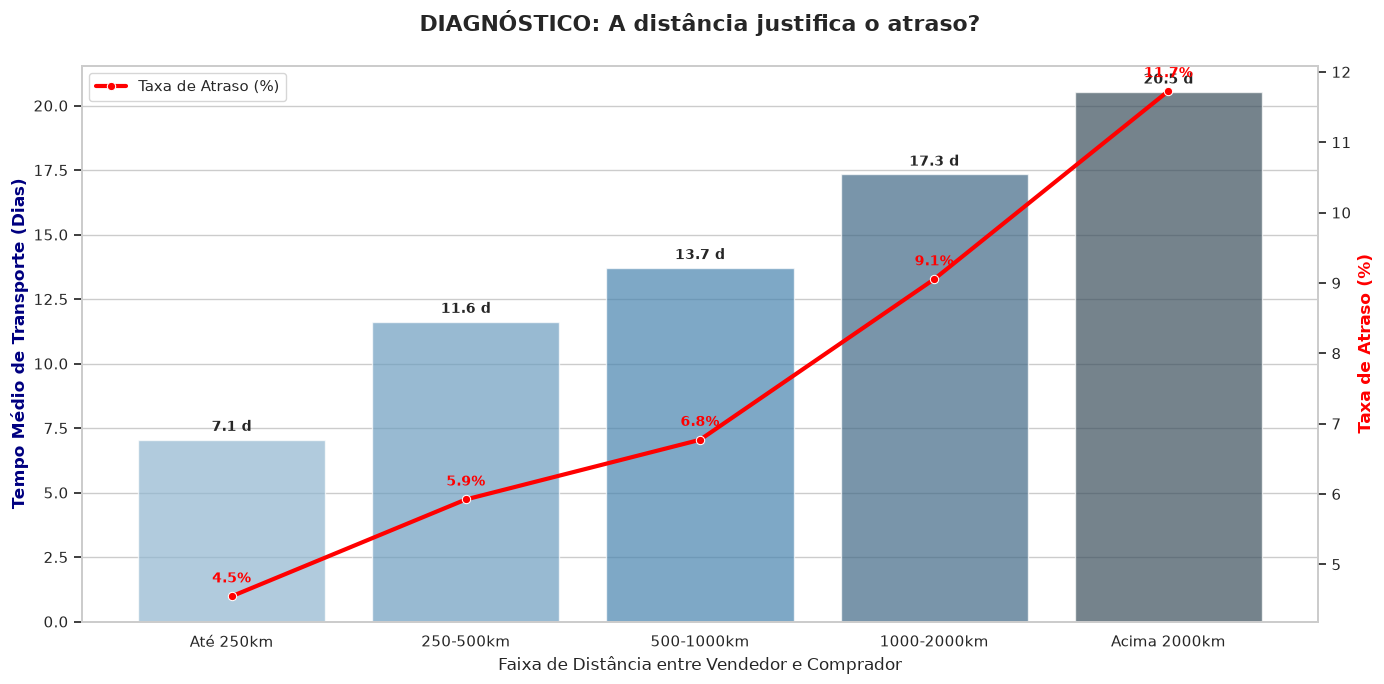

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados para visualização
# Convertendo a taxa de atraso para porcentagem para facilitar a leitura executiva
analise_distancia["taxa_atraso_%"] = analise_distancia["foi_atraso"] * 100

fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 2. Criando as barras para o Tempo de Transporte (Eixo Y1)
grafico_barras = sns.barplot(
    data=analise_distancia,
    x="faixa_distancia",
    y="tempo_transporte",
    ax=ax1,
    palette="Blues_d",
    alpha=0.7,
)
ax1.set_ylabel(
    "Tempo Médio de Transporte (Dias)", fontsize=12, fontweight="bold", color="navy"
)
ax1.set_xlabel("Faixa de Distância entre Vendedor e Comprador", fontsize=12)

# 3. Criando a linha para a Taxa de Atraso (Eixo Y2)
ax2 = ax1.twinx()
grafico_linha = sns.lineplot(
    data=analise_distancia,
    x="faixa_distancia",
    y="taxa_atraso_%",
    ax=ax2,
    marker="o",
    color="red",
    linewidth=3,
    label="Taxa de Atraso (%)",
)
ax2.set_ylabel("Taxa de Atraso (%)", fontsize=12, fontweight="bold", color="red")
ax2.grid(False)  # Removendo a grade secundária para evitar poluição visual [3]

# 4. Elementos de Storytelling: Título e Rótulos
plt.title(
    "DIAGNÓSTICO: A distância justifica o atraso?",
    fontsize=16,
    fontweight="bold",
    pad=25,
)

# Adicionando rótulos de dados nas barras (Dias)
for p in grafico_barras.patches:
    ax1.annotate(
        f"{p.get_height():.1f} d",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

# Adicionando rótulos de dados na linha (%)
for x, y in zip(
    analise_distancia["faixa_distancia"],
    analise_distancia["taxa_atraso_%"],
    strict=False,
):
    ax2.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10,
        color="red",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# Baixa Avaliação

* Subpergunta: O índice de satisfação de 100% (Nota 5.0) em dezembro de 2016 pode ser considerado um benchmark de sucesso para a operação de larga escala da Olist?
  * *Insight:* Não. O resultado de dezembro de 2016 é um Outlier de Contexto
. Com um volume de apenas 1 pedido (N=1), a amostra não possui representatividade para generalizar conclusões

  * *Evidência Estatística:* O desvio padrão como NaN (Not a Number) confirma matematicamente que não houve variabilidade para ser medida, já que o cálculo exige pelo menos duas observações (divisor n−1)

   * Esse dado deve ser tratado apenas como fase piloto e desconsiderado em projeções futuras

* Subpergunta: O crescimento acelerado do volume de pedidos em 2017 comprometeu a estabilidade da satisfação do cliente?
  * *Insight:* Surpreendentemente, a operação demonstrou maturidade precoce. Entre janeiro (970 pedidos) e agosto de 2017 (5.051 pedidos), o volume cresceu mais de 5 vezes, mas o Desvio Padrão reduziu de 1.27 para 1.17.

  * *Evidência dos Dados:* Uma redução no desvio padrão enquanto o volume aumenta indica que os processos estão se tornando mais previsíveis e estáveis

  * A nota média subindo de 4.19 para 4.28 prova que a Olist conseguiu escalar sem perder o controle da qualidade básica, estabelecendo o patamar de 4.28 como o KPI de "regime de cruzeiro"

* Subpergunta: Qual é a margem de incerteza real na percepção de valor do cliente após a estabilização do volume?
  * *Insight:* Embora a média seja alta (4.28), a variabilidade (1.17) indica que ainda há uma parcela significativa de clientes insatisfeitos "escondidos" atrás da média.

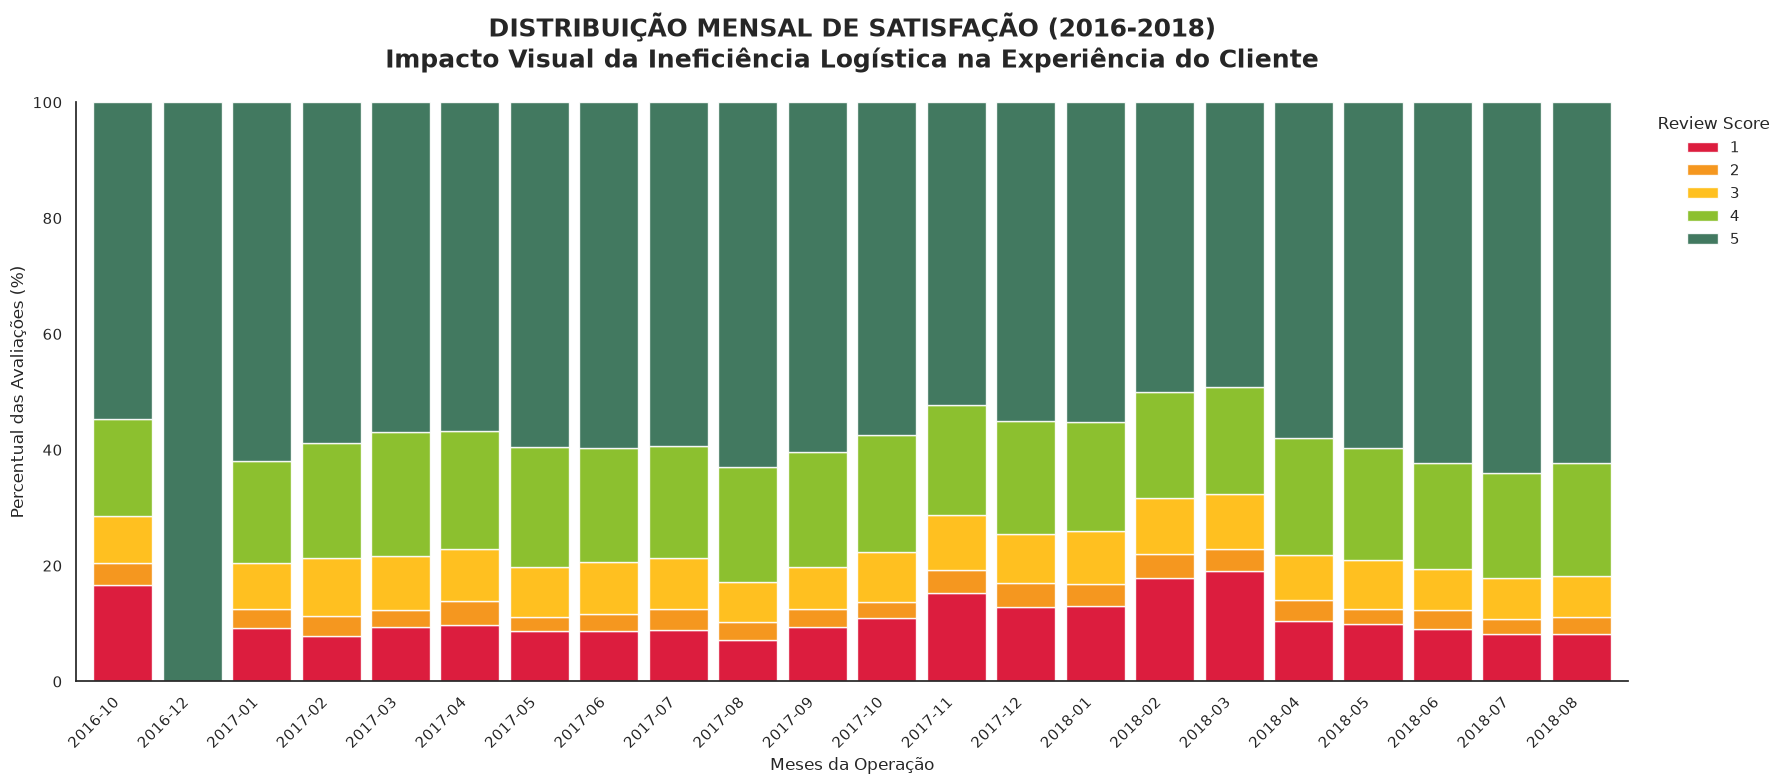

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparação da série temporal
# Garantindo que a data está em formato datetime e criando a coluna Ano-Mês
df_final["order_purchase_timestamp"] = pd.to_datetime(
    df_final["order_purchase_timestamp"]
)
df_final["ano_mes"] = df_final["order_purchase_timestamp"].dt.to_period("M").astype(str)

# 2. Cruzamento de dados e normalização para percentual (0-100%)
# O crosstab com normalize='index' calcula a distribuição de cada nota dentro de cada mês
dist_percentual = (
    pd.crosstab(df_final["ano_mes"], df_final["review_score"], normalize="index") * 100
)

# 3. Configuração Visual (Seguindo princípios de Storytelling)
plt.figure(figsize=(18, 8))
sns.set_theme(style="white")

# Cores Semânticas: Do Vermelho (Nota 1) ao Verde (Nota 5)
cores_satisfacao = ["#D90429", "#F48C06", "#FFBA08", "#80B918", "#2D6A4F"]

# Gerando o gráfico de barras empilhadas (Stacked Bar Chart)
dist_percentual.plot(
    kind="bar",
    stacked=True,
    color=cores_satisfacao,
    ax=plt.gca(),
    width=0.85,
    alpha=0.9,
)

# 4. Elementos de Storytelling e Design
plt.title(
    "DISTRIBUIÇÃO MENSAL DE SATISFAÇÃO (2016-2018)\nImpacto Visual da Ineficiência Logística na Experiência do Cliente",
    fontsize=18,
    fontweight="bold",
    pad=25,
)
plt.xlabel("Meses da Operação", fontsize=12)
plt.ylabel("Percentual das Avaliações (%)", fontsize=12)

# Ajuste de legenda e eixos
plt.legend(
    title="Review Score", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False
)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)

# Removendo bordas desnecessárias (Design Minimalista)
sns.despine()

plt.tight_layout()
plt.show()

In [21]:
# Agrupando por mês para ver a contagem de pedidos e a nota média
validacao_volume = (
    df_final.groupby("ano_mes")
    .agg(
        {"order_id": "count", "review_score": ["mean", "std"]}  # Média e Desvio Padrão
    )
    .reset_index()
)

# Renomeando as colunas para facilitar a leitura
validacao_volume.columns = ["Mes", "Total_Pedidos", "Nota_Media", "Desvio_Padrao"]

# Filtrando o início da operação para comparação
print(validacao_volume.head(10))

       Mes  Total_Pedidos  Nota_Media  Desvio_Padrao
0  2016-10            336    3.889881       1.509102
1  2016-12              1    5.000000            NaN
2  2017-01            970    4.197938       1.272069
3  2017-02           1959    4.183767       1.226171
4  2017-03           3072    4.135417       1.267491
5  2017-04           2701    4.100333       1.302677
6  2017-05           4272    4.199204       1.234169
7  2017-06           3700    4.186757       1.247214
8  2017-07           4737    4.165506       1.265799
9  2017-08           5051    4.284102       1.178463


# Clientes


*   **Subpergunta: Quem são os clientes mais afetados?**
    *   **Insight:** O atraso é um "assassino" de retenção. O risco está concentrado em **novos clientes (R\$ 824 mil)**, destruindo a possibilidade de LTV (*Lifetime Value*) logo na primeira compra.


In [22]:
# 1. Identificando frequência de compra por cliente único
frequencia_cliente = (
    df_final.groupby("customer_unique_id")["order_id"].nunique().reset_index()
)
frequencia_cliente.columns = ["customer_unique_id", "total_pedidos"]

# 2. Unindo ao DataFrame principal
df_final = df_final.merge(frequencia_cliente, on="customer_unique_id")

# 3. Criando o perfil: VIP (Mais de 1 pedido) vs Novo (1 pedido)
df_final["perfil_cliente"] = df_final["total_pedidos"].apply(
    lambda x: "VIP (Recorrente)" if x > 1 else "Novo Cliente"
)

# 4. Analisando o risco por perfil
risco_perfil = (
    df_final[df_final["foi_atraso"] & (df_final["review_score"] <= 2)]
    .groupby("perfil_cliente")["payment_value"]
    .sum()
    .reset_index()
)

print("Faturamento em Risco por Perfil de Cliente:")
print(risco_perfil)

Faturamento em Risco por Perfil de Cliente:
     perfil_cliente  payment_value
0      Novo Cliente      824994.55
1  VIP (Recorrente)       35061.96


/tmp/ipykernel_170804/2655742746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_perfil = sns.barplot(data=risco_perfil, x='perfil_cliente', y='payment_value', palette='OrRd_r')


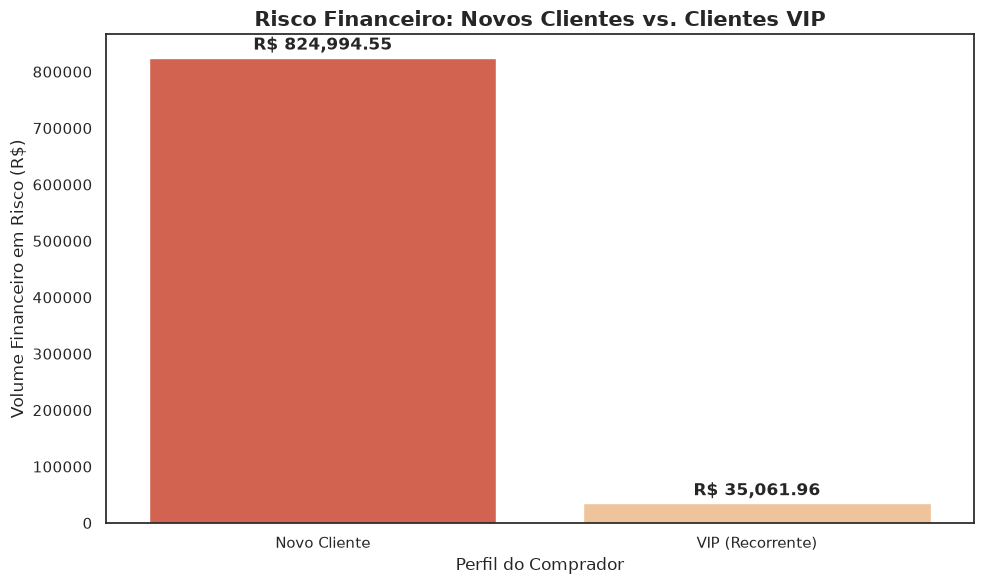

In [23]:
# 1. Configurando o gráfico de barras para Perfil de Cliente
plt.figure(figsize=(10, 6))
grafico_perfil = sns.barplot(
    data=risco_perfil, x="perfil_cliente", y="payment_value", palette="OrRd_r"
)

# 2. Adicionando títulos estratégicos
plt.title(
    "Risco Financeiro: Novos Clientes vs. Clientes VIP", fontsize=15, fontweight="bold"
)
plt.ylabel("Volume Financeiro em Risco (R$)")
plt.xlabel("Perfil do Comprador")

# 3. Colocando os rótulos de dados
for p in grafico_perfil.patches:
    grafico_perfil.annotate(
        f"R$ {p.get_height():,.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

* Subpergunta: O nível de satisfação na primeira compra influencia a decisão do cliente de retornar à plataforma Olist?
  * *Insight*: Sim. Atingir o nível de excelência (Nota 5 - Ótimo) é o principal motor de fidelização, resultando em uma Taxa de Retorno de 3,11%, a maior entre todas as categorias. Embora a diferença absoluta pareça pequena, proporcionalmente, um cliente "encantado" (Nota 5) tem uma propensão de retorno 12,8% maior do que um cliente que teve uma experiência apenas "boa" (Nota 4, com 2,75%).

   * *Evidência dos Dados:* A análise revela um fenômeno interessante: clientes insatisfeitos (Notas 1-3) apresentam uma taxa de retorno de 2,83%, ligeiramente superior aos que deram nota 4. Isso sugere que a Olist pode estar sendo eficaz em estratégias de "recuperação de serviço" (cupons de desconto ou reembolsos após reclamações), mas falha em converter o cliente "médio" (Nota 4) em um comprador recorrente

Taxa de Retorno por Satisfação Inicial:
   Categoria  Taxa_de_Retorno_%
0  1-3 (Mal)           2.833801
1    4 (Bom)           2.755241
2  5 (Ótimo)           3.107551


/tmp/ipykernel_170804/3770512047.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=taxa_retorno, x='Categoria', y='Taxa_de_Retorno_%', palette=paleta)


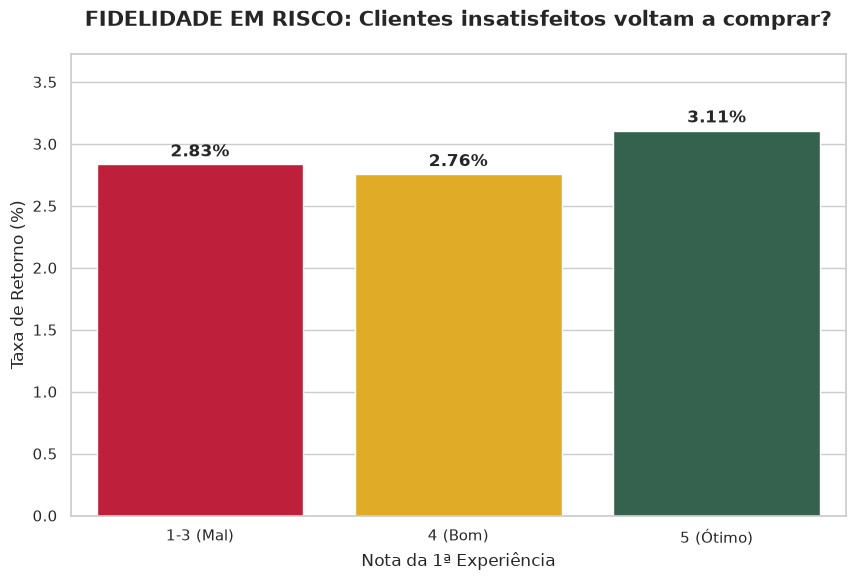

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Identificando a primeira experiência de cada cliente único
# Ordenamos por cliente e data para pegar o review_score do primeiro pedido
df_sorted = df_final.sort_values(["customer_unique_id", "order_purchase_timestamp"])
primeiro_pedido = df_sorted.groupby("customer_unique_id").first().reset_index()

# 2. Contando o total de pedidos por cliente para saber quem voltou
contagem_pedidos = (
    df_final.groupby("customer_unique_id")["order_id"].nunique().reset_index()
)
contagem_pedidos.columns = ["customer_unique_id", "total_pedidos"]

# 3. Cruzando a primeira nota com o comportamento de retorno
df_retencao = primeiro_pedido[["customer_unique_id", "review_score"]].merge(
    contagem_pedidos, on="customer_unique_id"
)
df_retencao["voltou_a_comprar"] = df_retencao["total_pedidos"] > 1


# 4. Categorizando as notas conforme solicitado
def categorizar(nota):
    if nota <= 3:
        return "1-3 (Mal)"
    if nota == 4:
        return "4 (Bom)"
    return "5 (Ótimo)"


df_retencao["satisfacao_inicial"] = df_retencao["review_score"].apply(categorizar)

# 5. Calculando a Taxa de Retorno por Categoria
taxa_retorno = (
    df_retencao.groupby("satisfacao_inicial")["voltou_a_comprar"].mean() * 100
)
taxa_retorno = taxa_retorno.reset_index()
taxa_retorno.columns = ["Categoria", "Taxa_de_Retorno_%"]

print("Taxa de Retorno por Satisfação Inicial:")
print(taxa_retorno)

# --- Gráfico de Storytelling ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
paleta = ["#D90429", "#FFBA08", "#2D6A4F"]  # Vermelho, Amarelo, Verde

grafico = sns.barplot(
    data=taxa_retorno, x="Categoria", y="Taxa_de_Retorno_%", palette=paleta
)

plt.title(
    "FIDELIDADE EM RISCO: Clientes insatisfeitos voltam a comprar?",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
plt.ylabel("Taxa de Retorno (%)", fontsize=12)
plt.xlabel("Nota da 1ª Experiência", fontsize=12)
plt.ylim(0, taxa_retorno["Taxa_de_Retorno_%"].max() * 1.2)

# Adicionando rótulos de dados
for p in grafico.patches:
    grafico.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontweight="bold",
    )

plt.show()